# Matrix-only CG/PINN flux reconstruction and MRST/TPFA transport control

This notebook is the matrix-only counterpart of the boundary-tip transport study. It keeps the three transport flux choices used in the comparison:

- raw CG flux `v_h`,
- CG+PINN reconstructed flux `v_theta`,
- MRST/TPFA finite-volume flux.

Only the matrix pressure, flux reconstruction, residual diagnostics, and matrix transport comparison are included.


In [1]:
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy.io import loadmat

try:
    import torch
    import torch.nn as nn
    from tqdm.auto import tqdm
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    torch = None
    nn = None
    TORCH_AVAILABLE = False

    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

np.random.seed(1234)
if TORCH_AVAILABLE:
    torch.manual_seed(1234)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = "numpy"

REF = 6
N_BULK = 2 ** (REF + 1)
K_M_VALUE = 1.0
P_LEFT = 1.0
P_RIGHT = 4.0

DATA_FILE = pathlib.Path("case3_ecmor/case3_mrst_export_nofrac.mat")
if not DATA_FILE.exists():
    matches = sorted(pathlib.Path.cwd().glob("**/case3_ecmor/case3_mrst_export_nofrac.mat"))
    DATA_FILE = matches[0] if matches else DATA_FILE
if not DATA_FILE.exists():
    raise FileNotFoundError("Could not find case3_mrst_export_nofrac.mat from the notebook directory or repository root.")

mrst = loadmat(DATA_FILE, squeeze_me=True, struct_as_record=False)


def _arr(key, dtype=float):
    if key not in mrst:
        raise KeyError(f"Missing MRST field {key!r}")
    return np.asarray(mrst[key], dtype=dtype)


def _meta_float(key, default=np.nan):
    if key not in mrst:
        return float(default)
    values = np.asarray(mrst[key]).reshape(-1)
    return float(values[0]) if values.size else float(default)

xc_matrix = _arr("xc_matrix", float)
p_matrix_mrst = _arr("p_matrix", float).reshape(-1)
face_neighbors = _arr("face_neighbors", np.int64)
face_flux_mrst = _arr("face_flux", float).reshape(-1)
face_centroid = _arr("face_centroid", float)
face_normal = _arr("face_normal", float)
face_len = _arr("face_len", float).reshape(-1)
face_p1 = _arr("face_p1", float)
face_p2 = _arr("face_p2", float)
face_is_boundary = _arr("face_is_boundary", bool).reshape(-1) if "face_is_boundary" in mrst else np.any(face_neighbors == 0, axis=1)

nx, ny = np.asarray(mrst.get("meta_celldim", [N_BULK, N_BULK]), dtype=int).reshape(-1)
physdim = np.asarray(mrst.get("meta_physdim", [1.0, 1.0]), dtype=float).reshape(-1)
phi_matrix = _meta_float("meta_phi_matrix", 1.0)
PV_matrix = _meta_float("meta_PV_matrix", phi_matrix * float(np.prod(physdim)))
Q_water = _meta_float("meta_Q_water", np.nan)
CFL = _meta_float("meta_CFL", 0.45)
FPRIME_MAX = _meta_float("meta_FPRIME_MAX", 2.0)

xmin, ymin = 0.0, 0.0
xmax, ymax = float(physdim[0]), float(physdim[1])
hx = physdim[0] / nx
hy = physdim[1] / ny
h_est = min(hx, hy)
ncell = int(xc_matrix.shape[0])
cell_area = np.full(ncell, float(np.prod(physdim)) / ncell, dtype=float)
cell_pv = phi_matrix * cell_area

transport_cases = []
if "sw_matrix_pvi05" in mrst:
    T_pvi05 = _meta_float("meta_T_pvi05")
    PVI_pvi05 = Q_water * T_pvi05 / PV_matrix if np.isfinite(Q_water) and PV_matrix > 0.0 else 0.5
    transport_cases.append(("PVI0.5", "sw_matrix_pvi05", "sw_matrix_pvi05_matched", T_pvi05, PVI_pvi05))
if "sw_matrix_t020" in mrst:
    transport_cases.append(("T0.2", "sw_matrix_t020", "sw_matrix_t020_matched", _meta_float("meta_T_t020"), _meta_float("meta_PVI_t020")))
if not transport_cases:
    transport_cases.append(("T1", "sw_matrix_t1", "sw_matrix_t1_matched", _meta_float("meta_T1"), _meta_float("meta_PVI1", 1.0)))
    if "sw_matrix_t2" in mrst:
        transport_cases.append(("T2", "sw_matrix_t2", "sw_matrix_t2_matched", _meta_float("meta_T2"), _meta_float("meta_PVI2")))

TRANSPORT_CASE_KEY = transport_cases[0][0]

print(f"Loaded {DATA_FILE}")
print(f"Matrix grid: {nx} x {ny}, cells={ncell}, faces={len(face_flux_mrst)}")
print(f"PV={PV_matrix:.8e}, Q_water={Q_water:.8e}, CFL={CFL:.3f}")
print("Available transport snapshots:")
for key, sw_key, _, tfinal, pvi in transport_cases:
    sw = _arr(sw_key, float).reshape(-1)
    print(f"  {key:<7} T={tfinal:.8e}, PVI={pvi:.6f}, S=[{sw.min():.3e}, {sw.max():.3e}]")


Loaded case3_ecmor/case3_mrst_export_nofrac.mat
Matrix grid: 128 x 128, cells=16384, faces=33024
PV=1.00000000e+00, Q_water=3.00000000e+00, CFL=0.450
Available transport snapshots:
  PVI0.5  T=1.66666667e-01, PVI=0.500000, S=[0.000e+00, 9.863e-01]
  T0.2    T=2.00000000e-01, PVI=0.600000, S=[0.000e+00, 9.884e-01]


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Matrix-only CG pressure and Darcy flux.
PRESSURE_GRAD_X = (P_RIGHT - P_LEFT) / physdim[0]


def p_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return P_LEFT + PRESSURE_GRAD_X * pts[:, 0]


def q_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    out = np.zeros((pts.shape[0], 2), dtype=float)
    out[:, 0] = -K_M_VALUE * PRESSURE_GRAD_X
    return out


def f_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return np.zeros(pts.shape[0], dtype=float)


def polygon_signed_area(poly):
    poly = np.asarray(poly, dtype=float)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1.0e-30)


def residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )

p_matrix_cg = p_cg_numpy(xc_matrix)
p_matrix_diff_cg_mrst = p_matrix_cg - p_matrix_mrst
print(f"CG pressure p_h range: [{p_matrix_cg.min():.6f}, {p_matrix_cg.max():.6f}]")
print(f"CG Darcy velocity v_h = ({-K_M_VALUE * PRESSURE_GRAD_X:.6f}, 0)")
print(
    "MRST pressure comparison: "
    f"mean|p_h-p_FV|={np.mean(np.abs(p_matrix_diff_cg_mrst)):.3e}, "
    f"max|p_h-p_FV|={np.max(np.abs(p_matrix_diff_cg_mrst)):.3e}"
)


CG pressure p_h range: [1.011719, 3.988281]
CG Darcy velocity v_h = (-3.000000, 0)
MRST pressure comparison: mean|p_h-p_FV|=4.397e-13, max|p_h-p_FV|=6.772e-13


In [3]:
# CG+PINN reconstruction. For this matrix-only linear case, the conservative
# target correction is zero, so the network is trained as r_theta ~= 0 with
# divergence and y-boundary no-flow regularization.
RUN_PINN_TRAINING = True
PINN_EPOCHS = 50
PINN_N_INTERIOR = 8192
PINN_N_BOUNDARY = 2048
PINN_LR = 1.0e-3
W_CORRECTION_DATA = 1.0
W_DIV = 0.1
W_NOFLOW = 1.0
pinn_history = {"epoch": [], "loss": [], "data": [], "div": [], "noflow": []}
pinn_training_time = 0.0

if TORCH_AVAILABLE:
    class CorrectionFluxNet(nn.Module):
        def __init__(self, hidden_dim=32, depth=2):
            super().__init__()
            layers = []
            last = 2
            for _ in range(depth):
                layer = nn.Linear(last, hidden_dim)
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layers += [layer, nn.Tanh()]
                last = hidden_dim
            out = nn.Linear(last, 2)
            nn.init.zeros_(out.weight)
            nn.init.zeros_(out.bias)
            layers.append(out)
            self.net = nn.Sequential(*layers)
            self.register_buffer("center", torch.tensor([0.5 * physdim[0], 0.5 * physdim[1]], dtype=torch.float32))
            self.register_buffer("scale", torch.tensor(max(physdim), dtype=torch.float32))

        def forward(self, x):
            z = 2.0 * (x - self.center) / self.scale
            return self.net(z)

    def div_correction(net, x):
        x = x.clone().detach().requires_grad_(True)
        r = net(x)
        dr0 = torch.autograd.grad(r[:, 0].sum(), x, create_graph=True, retain_graph=True)[0][:, 0]
        dr1 = torch.autograd.grad(r[:, 1].sum(), x, create_graph=True, retain_graph=True)[0][:, 1]
        return dr0 + dr1

    correction_net = CorrectionFluxNet().to(device)

    if RUN_PINN_TRAINING:
        opt = torch.optim.Adam(correction_net.parameters(), lr=PINN_LR)
        t0 = time.perf_counter()
        for epoch in tqdm(range(PINN_EPOCHS), desc="Matrix-only PINN correction"):
            opt.zero_grad(set_to_none=True)
            x_int_np = np.column_stack([
                np.random.rand(PINN_N_INTERIOR) * physdim[0],
                np.random.rand(PINN_N_INTERIOR) * physdim[1],
            ])
            x_int = torch.as_tensor(x_int_np, dtype=torch.float32, device=device)
            r_int = correction_net(x_int)
            data_loss = torch.mean(r_int ** 2)
            div_loss = torch.mean(div_correction(correction_net, x_int) ** 2)

            xb = np.random.rand(PINN_N_BOUNDARY) * physdim[0]
            yb = np.where(np.random.rand(PINN_N_BOUNDARY) < 0.5, 0.0, physdim[1])
            x_bnd = torch.as_tensor(np.column_stack([xb, yb]), dtype=torch.float32, device=device)
            r_bnd = correction_net(x_bnd)
            noflow_loss = torch.mean(r_bnd[:, 1] ** 2)

            loss = W_CORRECTION_DATA * data_loss + W_DIV * div_loss + W_NOFLOW * noflow_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(correction_net.parameters(), max_norm=1.0)
            opt.step()

            if epoch == 0 or epoch == PINN_EPOCHS - 1 or (epoch + 1) % max(1, PINN_EPOCHS // 5) == 0:
                pinn_history["epoch"].append(epoch + 1)
                pinn_history["loss"].append(float(loss.detach().cpu()))
                pinn_history["data"].append(float(data_loss.detach().cpu()))
                pinn_history["div"].append(float(div_loss.detach().cpu()))
                pinn_history["noflow"].append(float(noflow_loss.detach().cpu()))
        pinn_training_time = time.perf_counter() - t0

    def correction_numpy(points, batch=200000):
        correction_net.eval()
        pts = np.asarray(points, dtype=np.float32).reshape(-1, 2)
        out = []
        with torch.no_grad():
            for i0 in range(0, len(pts), batch):
                xb = torch.as_tensor(pts[i0:i0 + batch], dtype=torch.float32, device=device)
                out.append(correction_net(xb).cpu().numpy().astype(float))
        return np.vstack(out) if out else np.zeros((0, 2), dtype=float)
else:
    correction_net = None

    def correction_numpy(points, batch=200000):
        pts = np.asarray(points, dtype=float).reshape(-1, 2)
        return np.zeros((pts.shape[0], 2), dtype=float)


def q_rec_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return q_cg_numpy(pts) + correction_numpy(pts)

probe = np.random.rand(10000, 2) * physdim[None, :]
r_probe = correction_numpy(probe)
print(f"Torch available for PINN training: {TORCH_AVAILABLE}")
print(f"PINN correction training time: {pinn_training_time:.3f} s")
print(f"PINN correction |r_theta|: mean={np.mean(np.linalg.norm(r_probe, axis=1)):.3e}, max={np.max(np.linalg.norm(r_probe, axis=1)):.3e}")
if pinn_history["epoch"]:
    print("PINN correction loss history:")
    for e, loss, data, div, nf in zip(pinn_history["epoch"], pinn_history["loss"], pinn_history["data"], pinn_history["div"], pinn_history["noflow"]):
        print(f"  epoch={e:4d} loss={loss:.3e} data={data:.3e} div={div:.3e} noflow={nf:.3e}")


Matrix-only PINN correction: 100%|██████████| 50/50 [00:01<00:00, 37.18it/s]

Torch available for PINN training: True
PINN correction training time: 1.349 s
PINN correction |r_theta|: mean=0.000e+00, max=0.000e+00
PINN correction loss history:
  epoch=   1 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=  10 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=  20 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=  30 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=  40 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=  50 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00


In [4]:
# MRST face orientation -> owner/neighbour records.
n1 = face_neighbors[:, 0].astype(int)
n2 = face_neighbors[:, 1].astype(int)
is_internal_face = (n1 > 0) & (n2 > 0)
is_boundary_face = ~is_internal_face

owner_int = n1[is_internal_face] - 1
neigh_int = n2[is_internal_face] - 1
owner_b = np.maximum(n1[is_boundary_face], n2[is_boundary_face]) - 1
sgn_b = np.ones(np.count_nonzero(is_boundary_face), dtype=float)
sgn_b[n1[is_boundary_face] == 0] = -1.0

owner = np.concatenate([owner_int, owner_b]).astype(int)
neigh = np.concatenate([neigh_int, -np.ones_like(owner_b)]).astype(int)
has_neighbor = neigh >= 0
is_boundary_conn = ~has_neighbor

RIGHT_BC_S = 1.0
inlet_s_b = np.zeros_like(owner_b, dtype=float)
inlet_s_b[np.isclose(face_centroid[is_boundary_face, 0], physdim[0], atol=1.0e-10)] = RIGHT_BC_S
inlet_s = np.concatenate([np.zeros_like(owner_int, dtype=float), inlet_s_b])


def global_face_flux_to_fout(global_face_flux):
    global_face_flux = np.asarray(global_face_flux, dtype=float).reshape(-1)
    return np.concatenate([
        global_face_flux[is_internal_face],
        global_face_flux[is_boundary_face] * sgn_b,
    ]).astype(float)


def face_global_flux_from_velocity(velocity_fn, n_quad=2):
    if n_quad == 1:
        xi = np.array([0.5], dtype=float)
        wi = np.array([1.0], dtype=float)
    else:
        xi, wi = np.polynomial.legendre.leggauss(n_quad)
        xi = 0.5 * (xi + 1.0)
        wi = 0.5 * wi
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = velocity_fn(pts)
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux

face_flux_cg_global = face_global_flux_from_velocity(q_cg_numpy, n_quad=1)
face_flux_rec_global = face_global_flux_from_velocity(q_rec_numpy, n_quad=2)
Fout_CG = global_face_flux_to_fout(face_flux_cg_global)
Fout_PINN = global_face_flux_to_fout(face_flux_rec_global)
Fout_MRST = global_face_flux_to_fout(face_flux_mrst)

transport_fluxes = {"CG": Fout_CG, "PINN": Fout_PINN, "MRST": Fout_MRST}


def cell_single_phase_residual(Fout):
    residual = np.zeros(ncell, dtype=float)
    np.add.at(residual, owner, Fout)
    np.add.at(residual, neigh[has_neighbor], -Fout[has_neighbor])
    return residual

print("Face-flux comparison relative to MRST/TPFA:")
for name, Fout in transport_fluxes.items():
    err = Fout - Fout_MRST
    print(f"  {name:<4} mean|F-F_FV|={np.mean(np.abs(err)):.3e}, rmse={np.sqrt(np.mean(err**2)):.3e}, max|F-F_FV|={np.max(np.abs(err)):.3e}")

print("Single-phase cell balance, sum outward face flux:")
for name, Fout in transport_fluxes.items():
    r = cell_single_phase_residual(Fout)
    print(f"  {name:<4} {residual_stats(r)}")

print("Top/bottom no-flow audit:")
for side, yval in [("bottom", ymin), ("top", ymax)]:
    full_mask = is_boundary_face & np.isclose(face_centroid[:, 1], yval, atol=1.0e-12)
    print(
        f"  {side:<6} CG sum|F|={np.sum(np.abs(face_flux_cg_global[full_mask])):.3e}, "
        f"PINN sum|F|={np.sum(np.abs(face_flux_rec_global[full_mask])):.3e}, "
        f"MRST sum|F|={np.sum(np.abs(face_flux_mrst[full_mask])):.3e}"
    )


Face-flux comparison relative to MRST/TPFA:
  CG   mean|F-F_FV|=5.506e-15, rmse=8.585e-15, max|F-F_FV|=2.842e-14
  PINN mean|F-F_FV|=5.506e-15, rmse=8.585e-15, max|F-F_FV|=2.842e-14
  MRST mean|F-F_FV|=0.000e+00, rmse=0.000e+00, max|F-F_FV|=0.000e+00
Single-phase cell balance, sum outward face flux:
  CG   n=16384 mean|R|=0.000000e+00 median|R|=0.000000e+00 rmse=0.000000e+00 max|R|=0.000000e+00 sum(R)=+0.000000e+00
  PINN n=16384 mean|R|=0.000000e+00 median|R|=0.000000e+00 rmse=0.000000e+00 max|R|=0.000000e+00 sum(R)=+0.000000e+00
  MRST n=16384 mean|R|=8.921629e-16 median|R|=6.661338e-16 rmse=1.268817e-15 max|R|=1.332268e-14 sum(R)=+5.080381e-12
Top/bottom no-flow audit:
  bottom CG sum|F|=0.000e+00, PINN sum|F|=0.000e+00, MRST sum|F|=0.000e+00
  top    CG sum|F|=0.000e+00, PINN sum|F|=0.000e+00, MRST sum|F|=0.000e+00


Rotated rectangular transport-CV residual R_zeta
  rectangles: 16744
  angle=45 deg, Hu=0.0078125, Hv=0.0078125, shift=(0.00242187, 0.00367187)
  CG  : n=16744 mean|R|=6.045217e-20 median|R|=0.000000e+00 rmse=5.167665e-18 max|R|=6.643991e-16 sum(R)=+9.237403e-16
  PINN: n=16744 mean|R|=6.045217e-20 median|R|=0.000000e+00 rmse=5.167665e-18 max|R|=6.643991e-16 sum(R)=+9.237403e-16
  CG   sum(R_zeta^2)=4.471445e-31, RMSE=5.167665e-18
  PINN sum(R_zeta^2)=4.471445e-31, RMSE=5.167665e-18


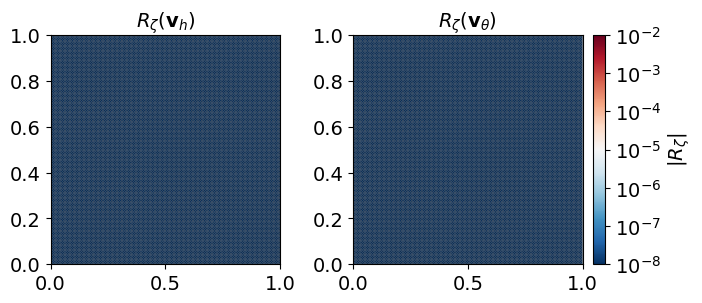

In [5]:
# Rotated rectangular transport-CV residual R_zeta.
ROT_RECT_ANGLE_DEG = 45.0
ROT_RECT_HU = 1.0 * h_est
ROT_RECT_HV = 1.0 * h_est
ROT_RECT_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
ROT_RECT_SHIFT_U = float(ROT_RECT_SHIFT_FRACTION[0] * ROT_RECT_HU)
ROT_RECT_SHIFT_V = float(ROT_RECT_SHIFT_FRACTION[1] * ROT_RECT_HV)
ROT_RECT_EDGE_NQ = 4
ROT_RECT_MIN_AREA = 1.0e-14
ROT_RECT_CMAP = "RdBu_r"
ROT_RECT_OUTLINE_COLOR = "0.25"
ROT_RECT_OUTLINE_WIDTH = 0.15
ROT_RECT_LOG_CLIM = (-8.0, -2.0)
ROT_RECT_COLORBAR_MODE = "shared"  # "shared" or "independent"


def clip_polygon_axis_bound(poly, axis, bound, keep_less, tol=1.0e-12):
    poly = [np.asarray(p, dtype=float) for p in poly]
    if not poly:
        return []

    def inside(p):
        return p[axis] <= bound + tol if keep_less else p[axis] >= bound - tol

    out = []
    prev = poly[-1]
    prev_in = inside(prev)
    for cur in poly:
        cur_in = inside(cur)
        if cur_in != prev_in:
            denom = cur[axis] - prev[axis]
            if abs(denom) > 1.0e-15:
                t = (bound - prev[axis]) / denom
                out.append(prev + t * (cur - prev))
        if cur_in:
            out.append(cur)
        prev, prev_in = cur, cur_in
    return out


def clip_polygon_to_bbox(poly):
    out = [np.asarray(p, dtype=float) for p in poly]
    for axis, bound, keep_less in [(0, xmin, False), (0, xmax, True), (1, ymin, False), (1, ymax, True)]:
        out = clip_polygon_axis_bound(out, axis, bound, keep_less)
        if len(out) == 0:
            return np.zeros((0, 2), dtype=float)
    return order_polygon_vertices(np.asarray(out, dtype=float))


def rotated_rect_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    H = float(H)
    if H <= 0.0:
        raise ValueError("The rotated-rectangle CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [float(lo), float(hi)]
    x = float(lo) + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_rotated_rectangles():
    theta = np.deg2rad(ROT_RECT_ANGLE_DEG)
    e_u = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    e_v = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    origin = np.array([xmin, ymin], dtype=float)
    bbox_poly = np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]], dtype=float)
    bbox_uv = np.column_stack(((bbox_poly - origin) @ e_u, (bbox_poly - origin) @ e_v))
    u_lines = rotated_rect_grid_lines(bbox_uv[:, 0].min(), bbox_uv[:, 0].max(), ROT_RECT_HU, ROT_RECT_SHIFT_U)
    v_lines = rotated_rect_grid_lines(bbox_uv[:, 1].min(), bbox_uv[:, 1].max(), ROT_RECT_HV, ROT_RECT_SHIFT_V)
    polys, centers, areas = [], [], []
    for u0, u1 in zip(u_lines[:-1], u_lines[1:]):
        for v0, v1 in zip(v_lines[:-1], v_lines[1:]):
            corners_uv = np.array([[u0, v0], [u1, v0], [u1, v1], [u0, v1]], dtype=float)
            rect_xy = origin + corners_uv[:, 0:1] * e_u[None, :] + corners_uv[:, 1:2] * e_v[None, :]
            poly = clip_polygon_to_bbox(rect_xy)
            if len(poly) < 3:
                continue
            area = abs(polygon_signed_area(poly))
            if area <= ROT_RECT_MIN_AREA:
                continue
            polys.append(poly)
            centers.append(poly.mean(axis=0))
            areas.append(float(area))
    return polys, np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def integrate_velocity_on_polygon(poly, velocity_fn):
    edge_q, edge_w = np.polynomial.legendre.leggauss(ROT_RECT_EDGE_NQ)
    edge_q = 0.5 * (edge_q + 1.0)
    edge_w = 0.5 * edge_w
    poly = order_polygon_vertices(poly)
    centroid = poly.mean(axis=0)
    total = 0.0
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        seg = x1 - x0
        seg_len = edge_length(x0, x1)
        if seg_len <= 1.0e-15:
            continue
        n_len = outward_edge_normal(x0, x1, centroid) * seg_len
        xq = x0[None, :] + edge_q[:, None] * seg[None, :]
        q = velocity_fn(xq)
        total += float(np.sum(edge_w * (q @ n_len)))
    return total

rotated_rect_polys, rotated_rect_centers, rotated_rect_areas = build_rotated_rectangles()
R_rotated_rect_cg = np.asarray([integrate_velocity_on_polygon(poly, q_cg_numpy) for poly in rotated_rect_polys], dtype=float)
R_rotated_rect_rec = np.asarray([integrate_velocity_on_polygon(poly, q_rec_numpy) for poly in rotated_rect_polys], dtype=float)

print("Rotated rectangular transport-CV residual R_zeta")
print(f"  rectangles: {len(rotated_rect_polys)}")
print(f"  angle={ROT_RECT_ANGLE_DEG:.6g} deg, Hu={ROT_RECT_HU:.6g}, Hv={ROT_RECT_HV:.6g}, shift=({ROT_RECT_SHIFT_U:.6g}, {ROT_RECT_SHIFT_V:.6g})")
print("  CG  :", residual_stats(R_rotated_rect_cg))
print("  PINN:", residual_stats(R_rotated_rect_rec))
for name, vals in [("CG", R_rotated_rect_cg), ("PINN", R_rotated_rect_rec)]:
    vals = vals[np.isfinite(vals)]
    print(f"  {name:<4} sum(R_zeta^2)={np.sum(vals**2):.6e}, RMSE={np.sqrt(np.mean(vals**2)):.6e}")

_abs_R_cg = np.abs(R_rotated_rect_cg)
_abs_R_rec = np.abs(R_rotated_rect_rec)
log_R_cg = np.log10(_abs_R_cg + 1.0e-30)
log_R_rec = np.log10(_abs_R_rec + 1.0e-30)


def _format_abs_tick(log_value):
    value = 10.0 ** float(log_value)
    if value == 0.0:
        return "0"
    exponent = int(np.floor(np.log10(abs(value))))
    coeff = value / (10.0 ** exponent)
    if np.isclose(coeff, 1.0):
        return rf"$10^{{{exponent}}}$"
    return rf"${coeff:.1f}\!\times\!10^{{{exponent}}}$"

_panels = [(log_R_cg, r"$R_\zeta(\mathbf{v}_h)$"), (log_R_rec, r"$R_\zeta(\mathbf{v}_\theta)$")]
if ROT_RECT_COLORBAR_MODE == "shared":
    if ROT_RECT_LOG_CLIM is None:
        finite = np.concatenate([log_R_cg[np.isfinite(log_R_cg)], log_R_rec[np.isfinite(log_R_rec)]])
        vmin, vmax = float(np.min(finite)), float(np.max(finite))
    else:
        vmin, vmax = map(float, ROT_RECT_LOG_CLIM)
    fig, axes = plt.subplots(1, 2, figsize=(6.9, 3.1), constrained_layout=False)
    fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
    pc = None
    for ax, (vals, title) in zip(axes, _panels):
        pc = PolyCollection(rotated_rect_polys, edgecolors=ROT_RECT_OUTLINE_COLOR, linewidths=ROT_RECT_OUTLINE_WIDTH, cmap=ROT_RECT_CMAP)
        pc.set_array(vals)
        pc.set_clim(vmin, vmax)
        ax.add_collection(pc)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=14)
        ax.tick_params(labelsize=14)
        ax.grid(False)
    fig.canvas.draw()
    axpos = axes[-1].get_position()
    cax = fig.add_axes([axpos.x1 + 0.015, axpos.y0, 0.018, axpos.height])
    cbar = fig.colorbar(pc, cax=cax)
    ticks = np.arange(-8.0, -1.0, 1.0)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([rf"$10^{{{int(t)}}}$" for t in ticks])
    cbar.set_label(r"$|R_\zeta|$", fontsize=14)
    cbar.ax.tick_params(labelsize=14)
else:
    fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.1), constrained_layout=True)
    for ax, (vals, title) in zip(axes, _panels):
        finite = vals[np.isfinite(vals)]
        vmin, vmax = float(np.min(finite)), float(np.max(finite))
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
            vmin, vmax = -16.0, -1.0
        pc = PolyCollection(rotated_rect_polys, edgecolors=ROT_RECT_OUTLINE_COLOR, linewidths=ROT_RECT_OUTLINE_WIDTH, cmap=ROT_RECT_CMAP)
        pc.set_array(vals)
        pc.set_clim(vmin, vmax)
        ax.add_collection(pc)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=14)
        ax.tick_params(labelsize=14)
        ax.grid(False)
        cbar = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.02)
        ticks = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels([_format_abs_tick(t) for t in ticks])
        cbar.ax.tick_params(labelsize=14)
plt.show()


MRST/TPFA validation:
  matrix pressure          mean|e|=4.397e-13 median|e|=4.928e-13 rmse=4.834e-13 max|e|=6.772e-13 relL2=1.827e-13
  CG face flux             mean|e|=5.506e-15 median|e|=1.332e-15 rmse=8.585e-15 max|e|=2.842e-14 relL2=5.180e-13
  PINN face flux           mean|e|=5.506e-15 median|e|=1.332e-15 rmse=8.585e-15 max|e|=2.842e-14 relL2=5.180e-13


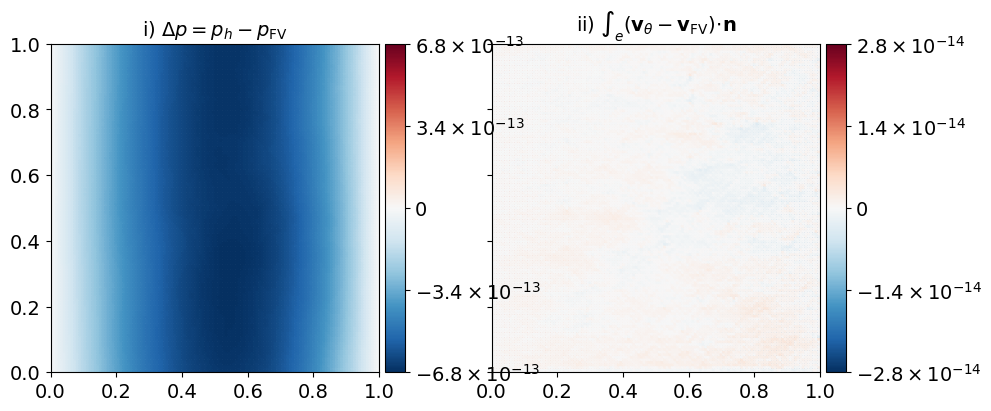

In [11]:
# MRST/TPFA validation maps.
def print_validation_stats(label, diff, ref=None):
    vals = np.asarray(diff, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        print(f"  {label:<24} no finite values")
        return
    rel = np.nan
    if ref is not None:
        r = np.asarray(ref, dtype=float).reshape(-1)
        denom = float(np.sqrt(np.sum(r ** 2)))
        if denom > 0.0:
            rel = float(np.sqrt(np.sum(vals ** 2)) / denom)
    print(
        f"  {label:<24} mean|e|={np.mean(np.abs(vals)):.3e} "
        f"median|e|={np.median(np.abs(vals)):.3e} rmse={np.sqrt(np.mean(vals**2)):.3e} "
        f"max|e|={np.max(np.abs(vals)):.3e} relL2={rel:.3e}"
    )

print("MRST/TPFA validation:")
print_validation_stats("matrix pressure", p_matrix_diff_cg_mrst, p_matrix_mrst)
print_validation_stats("CG face flux", face_flux_cg_global - face_flux_mrst, face_flux_mrst)
print_validation_stats("PINN face flux", face_flux_rec_global - face_flux_mrst, face_flux_mrst)


def _sci_cbar_tick_label(value):
    value = float(value)
    if not np.isfinite(value):
        return ""
    if abs(value) < 1.0e-300:
        return "0"
    exponent = int(np.floor(np.log10(abs(value))))
    coeff = value / (10.0 ** exponent)
    if np.isclose(abs(coeff), 1.0, rtol=0.0, atol=5.0e-3):
        sign = "-" if value < 0.0 else ""
        return rf"${sign}10^{{{exponent}}}$"
    return rf"${coeff:.1f}\times10^{{{exponent}}}$"


def _symmetric_absmax(values, floor=1.0e-15):
    vals = np.asarray(values, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return float(floor)
    lim = float(np.max(np.abs(vals)))
    if not np.isfinite(lim) or lim <= 0.0:
        lim = float(floor)
    return lim

from mpl_toolkits.axes_grid1 import make_axes_locatable
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    pdiff_lim = _symmetric_absmax(p_matrix_diff_cg_mrst)
    sc_p = axes[0].scatter(
        xc_matrix[:, 0], xc_matrix[:, 1], c=p_matrix_diff_cg_mrst,
        s=3, cmap="RdBu_r", vmin=-pdiff_lim, vmax=pdiff_lim, rasterized=True,
    )
    axes[0].set_xlim(xmin, xmax)
    axes[0].set_ylim(ymin, ymax)
    axes[0].set_aspect("equal")
    axes[0].set_title(r"i) $\Delta p=p_h-p_{\mathrm{FV}}$")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")
    axes[0].grid(False)
    div_p = make_axes_locatable(axes[0])
    cax_p = div_p.append_axes("right", size="6%", pad=0.06)
    cbar_p = fig.colorbar(sc_p, cax=cax_p)
    p_ticks = np.linspace(-pdiff_lim, pdiff_lim, 5)
    cbar_p.set_ticks(p_ticks)
    cbar_p.set_ticklabels([_sci_cbar_tick_label(t) for t in p_ticks])

    fdiff = face_flux_rec_global - face_flux_mrst
    fdiff_lim = _symmetric_absmax(fdiff)
    sc_f = axes[1].scatter(
        face_centroid[:, 0], face_centroid[:, 1], c=fdiff,
        s=2.5, cmap="RdBu_r", vmin=-fdiff_lim, vmax=fdiff_lim, rasterized=True,
    )
    axes[1].set_xlim(xmin, xmax)
    axes[1].set_ylim(ymin, ymax)
    axes[1].set_aspect("equal")
    axes[1].set_title(r"ii) $\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\!\cdot\!\mathbf{n}$")
    axes[1].set_xlabel("")
    axes[1].tick_params(labelleft=False)
    axes[1].grid(False)
    div_f = make_axes_locatable(axes[1])
    cax_f = div_f.append_axes("right", size="6%", pad=0.06)
    cbar_f = fig.colorbar(sc_f, cax=cax_f)
    f_ticks = np.linspace(-fdiff_lim, fdiff_lim, 5)
    cbar_f.set_ticks(f_ticks)
    cbar_f.set_ticklabels([_sci_cbar_tick_label(t) for t in f_ticks])
    plt.show()


In [7]:
# Explicit upwind Buckley-Leverett transport on the matrix cells.
def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def compute_transport_dt(Fout):
    outflow = np.zeros(ncell, dtype=float)
    np.add.at(outflow, owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, neigh[has_neighbor], np.maximum(-Fout[has_neighbor], 0.0))
    active = outflow > 1.0e-30
    if not np.any(active):
        raise RuntimeError("No outflow faces found for the fixed flux field.")
    return CFL * np.min(cell_pv[active] / (FPRIME_MAX * outflow[active]))


def advance_transport(Fout, t_final, clip=True, nsteps_override=None):
    Fout = np.asarray(Fout, dtype=float)
    dt_cfl = compute_transport_dt(Fout)
    if nsteps_override is None:
        nsteps = max(1, int(np.ceil(float(t_final) / dt_cfl)))
        dt_source = "method CFL"
    else:
        nsteps = max(1, int(nsteps_override))
        dt_source = "shared MRST/TPFA CFL"
    dt = float(t_final) / nsteps
    dt_over_pv = dt / cell_pv

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & is_boundary_conn
    boundary_outflow = outward & is_boundary_conn
    up_cell = np.empty_like(owner)
    up_cell[outward] = owner[outward]
    interior_negative = (~outward) & has_neighbor
    up_cell[interior_negative] = neigh[interior_negative]
    up_cell[incoming_boundary] = owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(inlet_s) * Fout

    S = np.zeros(ncell, dtype=float)
    cumulative_in = 0.0
    cumulative_out = 0.0
    preclip_min = 0.0
    preclip_max = 0.0
    clipped_count = 0
    clip_mass_delta = 0.0

    for _ in range(nsteps):
        water_flux = fractional_flow_bl(S[up_cell]) * Fout
        water_flux[incoming_boundary] = boundary_water_flux[incoming_boundary]
        wb = water_flux[is_boundary_conn]
        cumulative_in += dt * float(np.sum(np.maximum(-wb, 0.0)))
        cumulative_out += dt * float(np.sum(np.maximum(wb, 0.0)))

        div = np.zeros(ncell, dtype=float)
        np.add.at(div, owner, water_flux)
        np.add.at(div, neigh[has_neighbor], -water_flux[has_neighbor])
        S_new = S - dt_over_pv * div
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        if clip:
            S_clip = np.clip(S_new, 0.0, 1.0)
            clipped_count += int(np.count_nonzero(S_clip != S_new))
            clip_mass_delta += float(np.sum((S_clip - S_new) * cell_pv))
            S = S_clip
        else:
            S = S_new

    mass = float(np.sum(S * cell_pv))
    net = float(cumulative_in - cumulative_out)
    right_inflow = float(np.sum(np.maximum(-Fout[owner_int.size:], 0.0)))
    return S, {
        "T": float(t_final),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "nsteps": int(nsteps),
        "dt_source": dt_source,
        "water_in": float(cumulative_in),
        "water_out": float(cumulative_out),
        "water_net": net,
        "water_mass": mass,
        "water_balance_error": float(mass - net),
        "water_balance_error_pct_in": float(100.0 * (mass - net) / cumulative_in) if cumulative_in > 0.0 else np.nan,
        "preclip_min": float(preclip_min),
        "preclip_max": float(preclip_max),
        "clip_mass_delta": float(clip_mass_delta),
        "clipped_count": int(clipped_count),
        "right_inflow": right_inflow,
        "pvi": float(t_final * right_inflow / PV_matrix),
    }


def rmse(a, b):
    d = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    return float(np.sqrt(np.mean(d * d)))


def maxabs(a, b):
    return float(np.max(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))

TRANSPORT_CLIP = True
TRANSPORT_USE_SHARED_DT = True
reference_dt = compute_transport_dt(Fout_MRST)
reference_nsteps = {key: max(1, int(np.ceil(tfinal / reference_dt))) for key, _, _, tfinal, _ in transport_cases}

transport_results = {}
for key, sw_key, matched_key, tfinal, pvi in transport_cases:
    transport_results[key] = {}
    nsteps_ref = reference_nsteps[key] if TRANSPORT_USE_SHARED_DT else None
    for name, Fout in transport_fluxes.items():
        S, meta = advance_transport(Fout, tfinal, clip=TRANSPORT_CLIP, nsteps_override=nsteps_ref)
        transport_results[key][name] = {"S": S, "meta": meta}

transport_rect_saturation = {name: transport_results[TRANSPORT_CASE_KEY][name]["S"] for name in transport_fluxes}
transport_rect_meta = {name: transport_results[TRANSPORT_CASE_KEY][name]["meta"] for name in transport_fluxes}
transport_rect_method_names = np.asarray(["CG", "PINN", "MRST"], dtype=object)
transport_rect_S = np.vstack([transport_rect_saturation[name] for name in transport_rect_method_names])
transport_rect_water_mass = np.asarray([transport_rect_meta[name]["water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_net = np.asarray([transport_rect_meta[name]["water_net"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error = np.asarray([transport_rect_meta[name]["water_balance_error"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error_pct_in = np.asarray([transport_rect_meta[name]["water_balance_error_pct_in"] for name in transport_rect_method_names], dtype=float)
transport_rect_dt = np.asarray([transport_rect_meta[name]["dt"] for name in transport_rect_method_names], dtype=float)
transport_rect_nsteps = np.asarray([transport_rect_meta[name]["nsteps"] for name in transport_rect_method_names], dtype=np.int32)

print("Shared transport timestep policy:")
for key, _, _, tfinal, pvi in transport_cases:
    print(f"  {key:<7} nsteps_ref={reference_nsteps[key]}, dt_ref={tfinal/reference_nsteps[key]:.8e}, PVI={pvi:.6f}")

print("Transport diagnostics relative to native MRST explicitTransport:")
print("  case    method  nsteps        dt       PVI       RMSE      max|e|    balance/in")
for key, sw_key, _, _, _ in transport_cases:
    native = _arr(sw_key, float).reshape(-1)
    for name in ["CG", "PINN", "MRST"]:
        item = transport_results[key][name]
        S = item["S"]
        meta = item["meta"]
        print(
            f"  {key:<7} {name:<5} {meta['nsteps']:7d} {meta['dt']:10.4e} {meta['pvi']:8.4f} "
            f"{rmse(S, native):9.3e} {maxabs(S, native):9.3e} {meta['water_balance_error_pct_in']:11.3e}%"
        )

print("Native MRST explicitTransport vs exported matched scheme:")
for key, sw_key, matched_key, _, _ in transport_cases:
    if matched_key in mrst:
        print(f"  {key:<7} RMSE={rmse(_arr(matched_key, float).reshape(-1), _arr(sw_key, float).reshape(-1)):.4e}")


Shared transport timestep policy:
  PVI0.5  nsteps_ref=285, dt_ref=5.84795322e-04, PVI=0.500000
  T0.2    nsteps_ref=342, dt_ref=5.84795322e-04, PVI=0.600000
Transport diagnostics relative to native MRST explicitTransport:
  case    method  nsteps        dt       PVI       RMSE      max|e|    balance/in
  PVI0.5  CG        285 5.8480e-04   0.5000 3.052e-03 3.189e-02   5.551e-13%
  PVI0.5  PINN      285 5.8480e-04   0.5000 3.052e-03 3.189e-02   5.551e-13%
  PVI0.5  MRST      285 5.8480e-04   0.5000 3.052e-03 3.189e-02  -2.442e-13%
  T0.2    CG        342 5.8480e-04   0.6000 3.214e-03 3.411e-02  -2.591e-13%
  T0.2    PINN      342 5.8480e-04   0.6000 3.214e-03 3.411e-02  -2.591e-13%
  T0.2    MRST      342 5.8480e-04   0.6000 3.214e-03 3.411e-02  -2.220e-13%
Native MRST explicitTransport vs exported matched scheme:
  PVI0.5  RMSE=3.0525e-03
  T0.2    RMSE=3.2138e-03


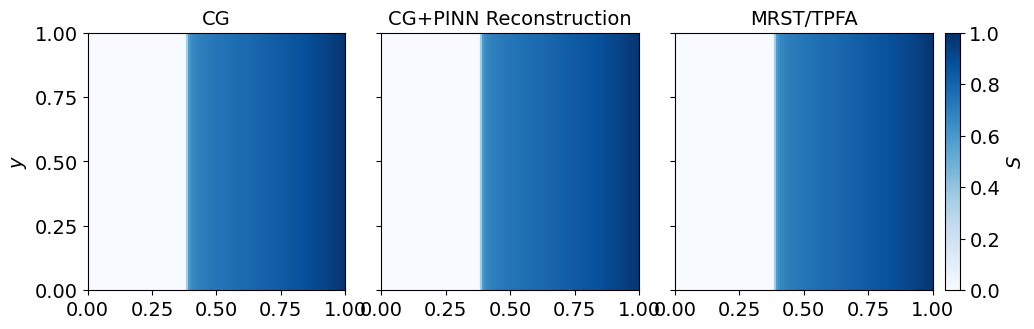

Selected case: PVI0.5, T=1.66666667e-01, PVI=0.500000
Saturation error relative to native MRST explicitTransport:
  CG-MRST   mean|e|=6.786e-04 rmse=3.052e-03 max|e|=3.189e-02
  PINN-MRST mean|e|=6.786e-04 rmse=3.052e-03 max|e|=3.189e-02
Global water mass balance on the matrix-only rectangular grid:
  method        stored water      net injected     balance error    error/in       nsteps       dt
  CG         5.000000e-01     5.000000e-01   2.775558e-15  5.551e-13%      285 5.8480e-04
  PINN       5.000000e-01     5.000000e-01   2.775558e-15  5.551e-13%      285 5.8480e-04
  MRST       5.000000e-01     5.000000e-01  -1.221245e-15 -2.442e-13%      285 5.8480e-04


In [8]:
# Saturation plots and final water balance for the selected matrix-only case.
def cell_field_to_grid(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    ix = np.rint((xc_matrix[:, 0] - 0.5 * hx) / hx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * hy) / hy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid

case_lookup = {key: (sw_key, matched_key, tfinal, pvi) for key, sw_key, matched_key, tfinal, pvi in transport_cases}
selected_sw_key, selected_matched_key, selected_T, selected_PVI = case_lookup[TRANSPORT_CASE_KEY]

x_edges = np.linspace(0.0, physdim[0], nx + 1)
y_edges = np.linspace(0.0, physdim[1], ny + 1)
plot_methods = ["CG", "PINN", "MRST"]
plot_titles = {"CG": "CG", "PINN": "CG+PINN Reconstruction", "MRST": "MRST/TPFA"}

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(10, 4.5))
    pcm = None
    for ax, name in zip(axes, plot_methods):
        field = transport_results[TRANSPORT_CASE_KEY][name]["S"]
        pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(field), cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
        ax.set_aspect("equal")
        ax.set_xlim(0.0, physdim[0])
        ax.set_ylim(0.0, physdim[1])
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_title(plot_titles[name])
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
    fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.95, wspace=0.14)
    fig.canvas.draw()
    pos = axes[-1].get_position()
    cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.015, pos.height])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$S$")
    plt.show()

native_selected = _arr(selected_sw_key, float).reshape(-1)
transport_rect_error_method_names = np.asarray(["CG-MRST", "PINN-MRST"], dtype=object)
transport_rect_S_error = np.vstack([
    transport_results[TRANSPORT_CASE_KEY]["CG"]["S"] - native_selected,
    transport_results[TRANSPORT_CASE_KEY]["PINN"]["S"] - native_selected,
])
print(f"Selected case: {TRANSPORT_CASE_KEY}, T={selected_T:.8e}, PVI={selected_PVI:.6f}")
print("Saturation error relative to native MRST explicitTransport:")
for name, err in zip(transport_rect_error_method_names, transport_rect_S_error):
    print(f"  {name:<9} mean|e|={np.mean(np.abs(err)):.3e} rmse={np.sqrt(np.mean(err**2)):.3e} max|e|={np.max(np.abs(err)):.3e}")

print("Global water mass balance on the matrix-only rectangular grid:")
print("  method        stored water      net injected     balance error    error/in       nsteps       dt")
for name in transport_rect_method_names:
    meta = transport_rect_meta[str(name)]
    print(
        f"  {str(name):<6} {meta['water_mass']:16.6e} {meta['water_net']:16.6e} "
        f"{meta['water_balance_error']:14.6e} {meta['water_balance_error_pct_in']:10.3e}% "
        f"{meta['nsteps']:8d} {meta['dt']:10.4e}"
    )


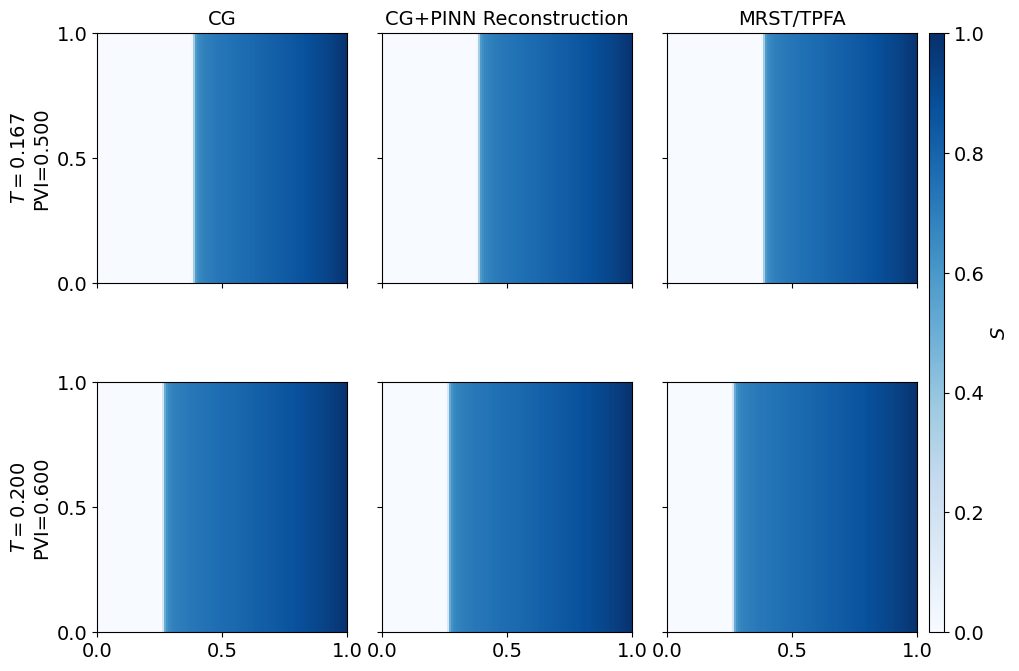

Time-step refinement check: shared dt versus shared dt/2
  PVI0.5  CG    RMSE=7.5596e-03, max|e|=5.9477e-02, nsteps_half=570
  PVI0.5  PINN  RMSE=7.5596e-03, max|e|=5.9477e-02, nsteps_half=570
  PVI0.5  MRST  RMSE=7.5596e-03, max|e|=5.9477e-02, nsteps_half=570
  T0.2    CG    RMSE=8.9653e-03, max|e|=9.7999e-02, nsteps_half=684
  T0.2    PINN  RMSE=8.9653e-03, max|e|=9.7999e-02, nsteps_half=684
  T0.2    MRST  RMSE=8.9653e-03, max|e|=9.7999e-02, nsteps_half=684


In [9]:
# Plot the exported time snapshots without rerunning transport.
row_cases = transport_cases[:2]
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(len(row_cases), 3, figsize=(10, 3.8 * len(row_cases)), squeeze=False)
    pcm = None
    for ir, (key, sw_key, _, tfinal, pvi) in enumerate(row_cases):
        for ic, name in enumerate(plot_methods):
            ax = axes[ir, ic]
            field = transport_results[key][name]["S"]
            pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(field), cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.set_aspect("equal")
            ax.set_xlim(0.0, physdim[0])
            ax.set_ylim(0.0, physdim[1])
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.grid(False)
            if ir == 0:
                ax.set_title(plot_titles[name])
            if ic == 0:
                ax.set_ylabel(rf"$T={tfinal:.3f}$" + "\n" + rf"PVI={pvi:.3f}")
            else:
                ax.tick_params(labelleft=False)
            if ir < len(row_cases) - 1:
                ax.tick_params(labelbottom=False)
    fig.subplots_adjust(left=0.08, right=0.90, bottom=0.07, top=0.94, wspace=0.14, hspace=0.12)
    top = axes[0, -1].get_position()
    bottom = axes[-1, -1].get_position()
    cax = fig.add_axes([top.x1 + 0.012, bottom.y0, 0.015, top.y1 - bottom.y0])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$S$")
    plt.show()

print("Time-step refinement check: shared dt versus shared dt/2")
for key, _, _, tfinal, _ in transport_cases:
    nsteps_ref = reference_nsteps[key]
    for name, Fout in transport_fluxes.items():
        S_dt = transport_results[key][name]["S"]
        S_half, meta_half = advance_transport(Fout, tfinal, clip=TRANSPORT_CLIP, nsteps_override=2 * nsteps_ref)
        print(f"  {key:<7} {name:<5} RMSE={rmse(S_dt, S_half):.4e}, max|e|={maxabs(S_dt, S_half):.4e}, nsteps_half={meta_half['nsteps']}")


In [10]:
# Save compact diagnostics for paper tables/figures.
outdir = pathlib.Path("result_koppel_martin_case1_pinn_matrix_only_control")
outdir.mkdir(exist_ok=True)
if TORCH_AVAILABLE and correction_net is not None:
    torch.save(
        {
            "correction_net": correction_net.state_dict(),
            "K_M_VALUE": K_M_VALUE,
            "P_LEFT": P_LEFT,
            "P_RIGHT": P_RIGHT,
            "xy_center": [0.5 * physdim[0], 0.5 * physdim[1]],
            "xy_scale": float(max(physdim)),
        },
        outdir / "matrix_only_pinn_correction.pt",
    )
np.savez(
    outdir / "diagnostics.npz",
    xc_matrix=xc_matrix,
    p_matrix_cg=p_matrix_cg,
    p_matrix_mrst=p_matrix_mrst,
    p_matrix_diff_cg_mrst=p_matrix_diff_cg_mrst,
    face_centroid=face_centroid,
    face_flux_mrst=face_flux_mrst,
    face_flux_cg=face_flux_cg_global,
    face_flux_pinn=face_flux_rec_global,
    R_zeta_cg=R_rotated_rect_cg,
    R_zeta_pinn=R_rotated_rect_rec,
    rotated_rect_centers=rotated_rect_centers,
    rotated_rect_areas=rotated_rect_areas,
    transport_method_names=transport_rect_method_names,
    transport_selected_case=TRANSPORT_CASE_KEY,
    transport_S=transport_rect_S,
    transport_water_mass=transport_rect_water_mass,
    transport_water_net=transport_rect_water_net,
    transport_water_balance_error=transport_rect_water_balance_error,
    transport_water_balance_error_pct_in=transport_rect_water_balance_error_pct_in,
    transport_dt=transport_rect_dt,
    transport_nsteps=transport_rect_nsteps,
)
print("saved:", outdir)


saved: result_koppel_martin_case1_pinn_matrix_only_control
